# **EDA: Dataset WESAD**

---
Iniciamos el EDA para el dataset [WESAD](https://doi.org/10.1145/3242969.3242985), un dataset multimodal para la detección de estrés y afecto utilizando datos fisiológicos y de cuestionarios.

---

## 1. Entendimiento Inicial y Carga de Datos
### 1.1 Importar librerías

Necesitamos las librerías estándar, más `os` para navegar por las carpetas y `pickle` para cargar los archivos `.pkl`.

In [70]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
from scipy import stats
from scipy.signal import decimate, resample

# Configuramos los gráficos
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Ruta principal del dataset
data_path = '../raw/WESAD/'

### 1.2 Inspección de la estructura de Datos (Un sujeto)

El README indica que cada sujeto tiene su propia carpeta (S2, S3, ...) y archivos `.pkl` para datos fisiológicos sincronizados y cuestionarios.

Primero listamos las carpetas de los sujetos y luego cargamos el archivo de un sujeto para inspeccionar su estructura interna. Esperamos encontrar un diccionario con las claves `subject`, `signal` y `label`.

In [2]:
# Cargamos los datos de un sujeto para inspección

# 1. Encontramos las carpetas de los sujetos
all_folders = [f for f in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, f))]

# Filtramos solo las carpetas que empiecen con S, además el README
# Indica que los sujetos S1 y S12 fueron descartados
subject_folders = sorted([f for f in all_folders if f.startswith('S') and f not in ['S1', 'S12']])
print(f'Se encontraron {len(subject_folders)} carpetas de sujetos')
print(subject_folders)

# 2. Cargamos el .pkl del primero para verlo
first_subject_id = subject_folders[0]
pkl_path = os.path.join(data_path, first_subject_id, f'{first_subject_id}.pkl')
print(f'\nCargando archivo del primer sujeto: {pkl_path}')

# Abrimos el archivo en modo rb (read binary)
with open(pkl_path, 'rb') as f:
    subject_data = pickle.load(f, encoding='latin1')
print('- Archivo cargado exitosamente.')

# Inspeccionamos la Estructura
print(f'\nTipo de datos cargados: {type(subject_data)}')
print(f'Keys principales del diccionario: {subject_data.keys()}')

# Inspeccionamos las keys de 'signal'
print(f'\nKeys dentro de "signal": {subject_data["signal"].keys()}')

# Inspeccionamos las keys de 'signal[chest]
print(f'\nKeys dentro de "signal[chest]": {subject_data["signal"]["chest"].keys()}')
# Inspeccionamos las keys de 'signal[wrist]'
print(f'\nKeys dentro de "signal[wrist]": {subject_data["signal"]["wrist"].keys()}')

Se encontraron 15 carpetas de sujetos
['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']

Cargando archivo del primer sujeto: ../raw/WESAD/S10\S10.pkl
- Archivo cargado exitosamente.

Tipo de datos cargados: <class 'dict'>
Keys principales del diccionario: dict_keys(['signal', 'label', 'subject'])

Keys dentro de "signal": dict_keys(['chest', 'wrist'])

Keys dentro de "signal[chest]": dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])

Keys dentro de "signal[wrist]": dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])


### 1.3 Inspeccion de Dimensiones (Shape) del Señales y Etiquetas
Ya que tenemos la estructura de las keys, ahora inspeccionamos las dimensiones de los arrays para el mismo sujeto, esto con el fin de verificar:
- La longitud de las señales del pecho (`chest`) y su consistencia
- La longitud de las señales de la muñeca (`wrist`) y sus frecuencias de muestreo
- La longitud de las etiquetas (`label`) y su correspondencia con las señales del pecho (ambas a 799 Hz según el README)

In [3]:
print(f'Sujeto: {subject_data["subject"]}')

# 1. Inspección de Señales del Pecho (chest)
# Estas deberían estar todas a 700 Hz
print('\n[CHEST] Señales (esperado: 700 Hz):')
chest_signals = subject_data['signal']['chest']
for signal_name, signal_data in chest_signals.items():
    print(f' - {signal_name}: shape = {signal_data.shape}')

# 2. Inspección de Señales de la Muñeca (wrist)
# Estas tienen diferentes SR
print('\n[WRIST] Señales (diferentes SR):')
wrist_signals = subject_data['signal']['wrist']
for signal_name, signal_data in wrist_signals.items():
    print(f' - {signal_name}: shape = {signal_data.shape}')

# 3. Inspección de Etiquetas (label)
print('\n[LABEL] Etiqueta de Condición:')
labels = subject_data['label']
print(f' - label: shape = {labels.shape}')

# Verificamos la consistencia
# Tomamos la longitud de la primera señal del pecho (ACC)
chest_len = chest_signals['ACC'].shape[0]
label_len = labels.shape[0]

if chest_len == label_len:
    print(f'\nVerificación exitosa: Longitud de "chest" ({chest_len}) coincide con longitud de "label" ({label_len}).')
else:
    print(f'\nVerificación fallida: Longitud de "chest" ({chest_len}) NO coincide con longitud de "label" ({label_len}).')

duracion_minutos = chest_len /(700*60)
print(f'Duración total aprox. de la grabación: {duracion_minutos:.2f} minutos')

Sujeto: S10

[CHEST] Señales (esperado: 700 Hz):
 - ACC: shape = (3847200, 3)
 - ECG: shape = (3847200, 1)
 - EMG: shape = (3847200, 1)
 - EDA: shape = (3847200, 1)
 - Temp: shape = (3847200, 1)
 - Resp: shape = (3847200, 1)

[WRIST] Señales (diferentes SR):
 - ACC: shape = (175872, 3)
 - BVP: shape = (351744, 1)
 - EDA: shape = (21984, 1)
 - TEMP: shape = (21984, 1)

[LABEL] Etiqueta de Condición:
 - label: shape = (3847200,)

Verificación exitosa: Longitud de "chest" (3847200) coincide con longitud de "label" (3847200).
Duración total aprox. de la grabación: 91.60 minutos


### 1.4 Análisis de Variable Objetivo (labels)
Los datos del pecho y etiquetas están alineados.
Ahora, antes de cargar a todos los sujetos vamos a analizar el label para este primero. El README indica que las etiquetas son:
* `0`: No definido / Transitorio
* `1`: Línea base (Baseline)
* `2`: Estrés (Stress)
* `3`: Diversión (Amusement)
* `4`: Meditación (Meditation)
* `5, 6, 7`: Ignorar

Vamos a contar cuántas muestras (y cuánto tiempo) corresponden a cada condición.

- Distribución de Etiquetas para el sujeto S10:
- Frecuencia de muestreo (SR): 700 Hz
Resumen de condiciones para el sujeto:


,label_id,label_name,sample_count,duration_sec,duration_min
0,0,Transient,1589000,2270.0,37.833333
1,1,Baseline,826000,1180.0,19.666667
2,2,Stress,507500,725.0,12.083333
3,3,Amusement,260400,372.0,6.200000
4,4,Meditation,557200,796.0,13.266667
5,5,Ignore_5,35700,51.0,0.850000
6,6,Ignore_6,31500,45.0,0.750000
7,7,Ignore_7,39900,57.0,0.950000


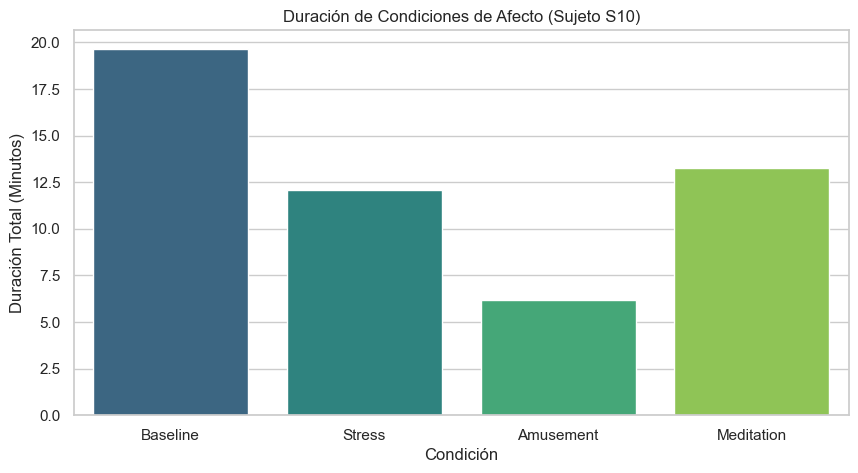

In [4]:
# Identificación y Distribución de Clases para un sujeto

# El array de etiquetas ya está cargado en 'labels'
labels_id, sample_counts = np.unique(labels, return_counts=True)

# Mapeamos los IDs a nombres legibles según el README
label_map = {
    0: 'Transient',
    1: 'Baseline',
    2: 'Stress',
    3: 'Amusement',
    4: 'Meditation',
    5: 'Ignore_5',
    6: 'Ignore_6',
    7: 'Ignore_7'
}

print(f'- Distribución de Etiquetas para el sujeto {first_subject_id}:')
print(f'- Frecuencia de muestreo (SR): 700 Hz')

# Creamos un DataFrame para mejor visualización
df_labels_stest = pd.DataFrame({
    'label_id': labels_id,
    'label_name': [label_map.get(lid, 'Unknown') for lid in labels_id],
    'sample_count': sample_counts
})

# Calculamos la duración en segundos y minutos
sr = 700.0  # Frecuencia de muestreo
df_labels_stest['duration_sec'] = df_labels_stest['sample_count'] / sr
df_labels_stest['duration_min'] = df_labels_stest['duration_sec'] / 60.0

# Reordenamos las columnas
df_labels_stest = df_labels_stest[['label_id', 'label_name', 'sample_count', 'duration_sec', 'duration_min']]

print('Resumen de condiciones para el sujeto:')
display(df_labels_stest)

# Balance de clases (gráficos)
# Filtramos las labels que no son Transient o Ignore para el gráfico
plot_data = df_labels_stest[
    (df_labels_stest['label_id'] >= 0) & (df_labels_stest['label_id'] <= 4)
]

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_data, 
            x='label_name', 
            y='duration_min', 
            palette='viridis',
            hue='label_name', # Para el warning de seaborn
            legend=False,
            order=['Baseline', 'Stress', 'Amusement', 'Meditation']) 
plt.title(f'Duración de Condiciones de Afecto (Sujeto {first_subject_id})')
plt.xlabel('Condición')
plt.ylabel('Duración Total (Minutos)')
plt.show()


---
## 2. Aplanamiento de datos para todos los sujetos

El análisis de un sujeto fue exitoso, ahora repetiremos esto para todos los 15 encontrados.
El objetivo es crear un único DataFrame que resuma la duración en minutos de cada condicción para cada uno de los 15 participantes. Esto nos permitirá continuar con el análisis agregado de la variable objetivo.

- ¿Es la duración de cada condicción similar entre sujeto?
- En total, ¿cuánto tiempo de datos tenemos para cada condicción en todo el dataset?
- ¿Está balanceado el dataset?


In [5]:
# Ahora aplanamos los datos
sr = 700  # Frecuencia de muestreo para las señales del pecho

all_subjects_data = []
print(f'Iniciando carga y agregación de {len(subject_folders)} sujetos...')

# 1. Iteramos sobre cada sujeto
for subject_id in subject_folders:
    pkl_path = os.path.join(data_path, subject_id, f'{subject_id}.pkl')

    with open(pkl_path, 'rb') as f:
        subject_data = pickle.load(f, encoding='latin1')
    
    # Extraemos el achivo de etiquetas
    labels = subject_data['label']
    
    # Contamos las muestras para cada ID de etiqueta
    labels_id, sample_counts = np.unique(labels, return_counts=True)

    # Creamos una entrada para cada etiqueta encontrada por sujeto

    for i, label_id in enumerate(labels_id):
        sample_count = sample_counts[i]
        all_subjects_data.append({
            'subject_id': subject_id,
            'label_id': label_id,
            'label_name': label_map.get(label_id, f'Unknown_{label_id}'),
            'sample_count': sample_count,
            'duration_min': sample_count / (sr * 60.0)
        })

# 2. Convertimos la lista en un DataFrame
df_labels_agg = pd.DataFrame(all_subjects_data)
print('\nDatos agregados de todos los sujetos.')

# Vemos dimensiones y vistazo
print(f'Dataframe agregado, shape: {df_labels_agg.shape}')
print('\n Tipos de Datos:')
df_labels_agg.info()
print('\n Primeras filas del DataFrame agregado:')
print(df_labels_agg.head())

print('\n Muestras de un sujeto')
display(df_labels_agg[df_labels_agg['subject_id'] == 'S13'])

Iniciando carga y agregación de 15 sujetos...

Datos agregados de todos los sujetos.
Dataframe agregado, shape: (119, 5)

 Tipos de Datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   subject_id    119 non-null    object 
 1   label_id      119 non-null    int32  
 2   label_name    119 non-null    object 
 3   sample_count  119 non-null    int64  
 4   duration_min  119 non-null    float64
dtypes: float64(1), int32(1), int64(1), object(2)
memory usage: 4.3+ KB

 Primeras filas del DataFrame agregado:
  subject_id  label_id  label_name  sample_count  duration_min
0        S10         0   Transient       1589000     37.833333
1        S10         1    Baseline        826000     19.666667
2        S10         2      Stress        507500     12.083333
3        S10         3   Amusement        260400      6.200000
4        S10         4  Medi

,subject_id,label_id,label_name,sample_count,duration_min
16,S13,0,Transient,1679300,39.983333
17,S13,1,Baseline,826001,19.666690
18,S13,2,Stress,464800,11.066667
19,S13,3,Amusement,267400,6.366667
20,S13,4,Meditation,556499,13.249976
21,S13,5,Ignore_5,34300,0.816667
22,S13,6,Ignore_6,33600,0.800000
23,S13,7,Ignore_7,14000,0.333333


---

## 3. Análisis de la Variable Objetivo (labels) Agregado

Con el Dataframe agregado de duración por sujeto y condición, podemos analizar la distribución general de las etiquetas en todo el dataset.

Filtraremos las etiquetas que no nos interesan (Transient, Ignore) y nos centraremos en las 4 condiciones útiles.


Dimensiones de datos útiles (4 labels * 15 sujetos): (60, 5)

 Duración Total por Condición (Todo el Dataset):


,label_name,duration_min
0,Baseline,293.516714
1,Stress,166.100024
2,Amusement,92.916690
3,Meditation,196.766643


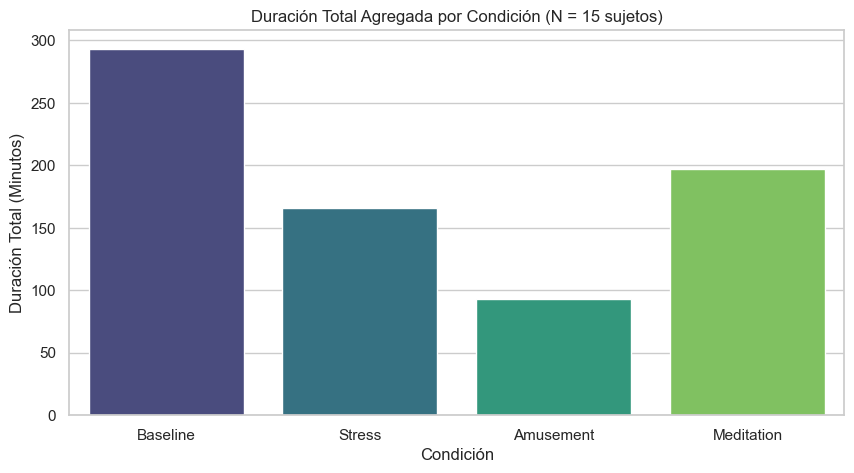

In [7]:
# 1. Filtramos solo las 4 condiciones útiles
useful_labels = ['Baseline', 'Stress', 'Amusement', 'Meditation']
df_useful_labels = df_labels_agg[df_labels_agg['label_name'].isin(useful_labels)].copy()

print(f'Dimensiones de datos útiles (4 labels * 15 sujetos): {df_useful_labels.shape}')

# 2. Calcular la duración total (sumando todos los sujetos)
df_total_duration = df_useful_labels.groupby('label_name')['duration_min'].sum().reset_index()

# Ordenarmos
label_order = ['Baseline', 'Stress', 'Amusement', 'Meditation']
df_total_duration = df_total_duration.set_index('label_name').loc[label_order].reset_index()

print('\n Duración Total por Condición (Todo el Dataset):')
display(df_total_duration)

# 3. Visualizar el balance total
plt.figure(figsize = (10, 5))
sns.barplot(data=df_total_duration, 
            x='label_name', 
            y='duration_min', 
            palette='viridis',
            hue = 'label_name',
            legend=False)
plt.title('Duración Total Agregada por Condición (N = 15 sujetos)')
plt.xlabel('Condición')
plt.ylabel('Duración Total (Minutos)')
plt.show()

La salida nos muestra la cantidad total de datos que tenemos para el modelado, el dataset está a primera vista desbalanceado con mucha más data de Baseline y menos data de Amusement (Diversión), con 3.15 veces más datos aprox entre estas dos.
Es crucial entender este desbalance al momento de entrenar la predicción, ya que puede afectar la capacidad del modelo para generalizar y hacer predicciones precisas en condiciones menos representadas. Necesiataremos un re-muestreo o el uso de métricas de evaluación robustas.


---

### 3.1 Análisis de Variabilidad entre Sujetos

EL gráfico anterior nos muestra el total, pero debemos determinar si esta duración es consistente en todos los sujetos o si hay variabilidad significativa entre ellos.
Para ello usaremos **BoxPlots** para visualizar la distribución de cada condición entre los 15 sujetos.

Distribución de Duraciones por Condición (N = 1 Sujetos)


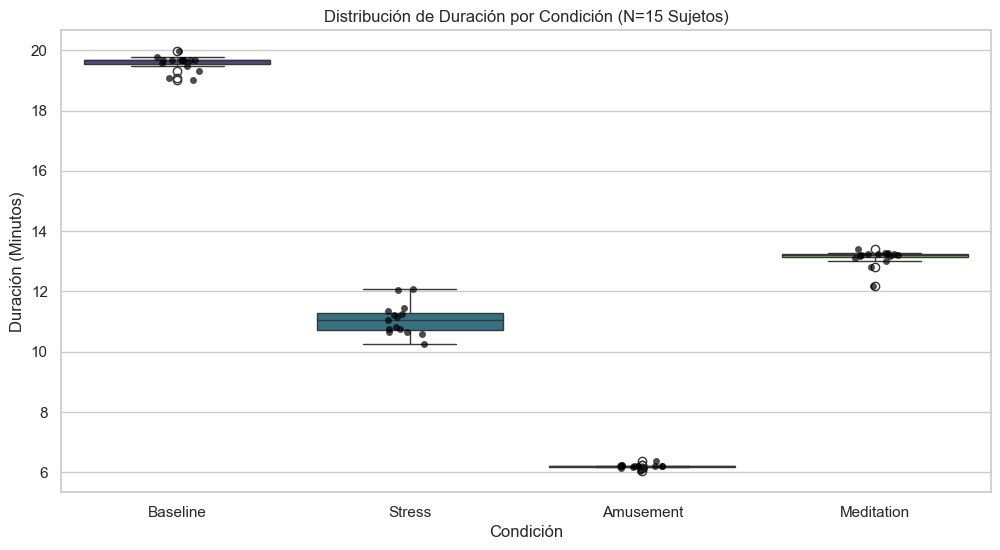


 Resumen Estadístico (Minutos por condición)


,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
Amusement,15.0,6.194446,0.070054,6.033333,6.183321,6.200000,6.200024,6.366667
Baseline,15.0,19.567781,0.258157,19.000000,19.533333,19.666667,19.666679,19.966667
Meditation,15.0,13.117776,0.293072,12.183333,13.141679,13.216667,13.241655,13.416667
Stress,15.0,11.073335,0.517350,10.250000,10.708333,11.066667,11.291667,12.083333


In [14]:
# Boxplots de duración por condición
print('Distribución de Duraciones por Condición (N = 1 Sujetos)')

# df_useful_labels tiene 15 entradas por cada label
# label_order ya lo definimos
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_useful_labels, 
            x='label_name', 
            y='duration_min', 
            palette='viridis',
            hue = 'label_name',
            legend = False,
            order = label_order)

# Superponemos un stripplot para ver los 15 puntos de datos individuales
sns.stripplot(data=df_useful_labels, 
              x ='label_name',
              y ='duration_min',
              order= label_order,
              color='black',
              alpha=0.7,
              jitter=0.1)
plt.title('Distribución de Duración por Condición (N=15 Sujetos)')
plt.xlabel('Condición')
plt.ylabel('Duración (Minutos)')
plt.show()

# Resumen Estadístico de las duraciones
print('\n Resumen Estadístico (Minutos por condición)')
display(df_useful_labels.groupby('label_name',observed = False)['duration_min'].describe())

El análisis de los boxplots y la info estadística de la variabilidad de duración entre sujetos nos muestran un hallazgo crucial:
Tiene excelente consistencia, con desviaciones estándar en duración extremadamente bajas, reflejando un protocolo muy rígido y controlado ya que todos los sujetos realizaron las tareas o exposiciones a las condiciones por periodos similares y cronometrados, ofreciendo un Dataset de alta calidad en cuanto a cantidad de datos pos sujeto por clase. Creando un dataset balanceado a nivel sujeto.


---

## 4. Análisis de Self-Reports

Hasta ahora, hemos analizado las etiquetas del protocolo. Sin embargo, el README y el csv nos propocionan self-reports de los sujetos después de cada condición. Específicamente incluyen distintos autoreportes:

1)  **SAM (Self-Assessment Manikins)**, que mide `Valence` (Valencia) y `Arousal` (Excitación) en una escala de 1 a 9.  

2) **PANAS**, que mide el Afecto positivo (PA) y Afecto negativo(NA).

3) **STAI**, que mide la Ansiedad de Estado

4) **SSSQ**, que mide constuctos como el compromiso, motivación y la 'preocupación por la impresión social'. Que los creadores del datset mencionan fue rellenado ***sólo después de la condición de estrés (TSST)***.

---

### 4.1 Análisis SAM:

Cargamos los archivos de cada sujeto para crear un DataFrame que relacione las condiciones del protocolo con las puntuaciones subjetivas de SAM.
Ya conocemos gracias al README la estructura de los archivos `SX_quest.csv`:
* El delimitador es `;`.
* Las líneas de SAM (Valence/Arousal) comienzan con `'# DIM'`.
* El orden de las 5 líneas `'# DIM'` corresponde al orden de las 5 condiciones definidas en la línea `'# ORDER'`.


In [24]:
# Cargamos y aplanamos los datos de los Self-Reports

# Mapeamos los nombres del CSV a nuestros nombres estándar
condition_map = {
    'Base': 'Baseline',
    'Fun': 'Amusement',
    'TSST': 'Stress',
    'Medi 1': 'Meditation_1',
    'Medi 2': 'Meditation_2'
}
all_sam_data = []
print(f'Cargando {len(subject_folders)} archivos "SX_quest.csv"')

for subject_id in subject_folders:
    quest_path = os.path.join(data_path, subject_id, f'{subject_id}_quest.csv')
    with open(quest_path, 'r') as f:
        lines = f.readlines()
    # 1. Encontramos la linea de ORDEn
    order_line = next(l for l in lines if l.startswith('# ORDER'))
    # Limpiamos y separamos. Tomando las 5 condiciones
    order = [name.strip() for name in order_line.split(';')[1:6]]

    # 2. Encontramos TODAS las líneas DIM
    dim_lines = [l for l in lines if l.startswith('# DIM')]

    # 3. Mapeamos
    # Iteramos sobre las 5 condiciones encontradas
    for i in range(len(dim_lines)):
        condition_name_raw = order[i]
        
        # Verificamos si es una de las que nos importan
        if condition_name_raw in condition_map:
            condition_name_clean = condition_map[condition_name_raw]

            # Paresamos la línea DIM correpondiente
            dim_parts = dim_lines[i].split(';')
            valence_score = int(dim_parts[1])
            arousal_score = int(dim_parts[2])

            all_sam_data.append({
                'subject_id': subject_id,
                'condition': condition_name_clean,
                'valence': valence_score,
                'arousal': arousal_score
            })

# 4. Convertimos a DataFrame
df_sam = pd.DataFrame(all_sam_data)
print("\n Agregación de SAM completada.")
# Esperado: (75, 4) -> 15 sujetos * 5 condiciones
print(f"DataFrame de SAM creado. Dimensiones: {df_sam.shape}") 
df_sam.info()
display(df_sam.head())


Cargando 15 archivos "SX_quest.csv"

 Agregación de SAM completada.
DataFrame de SAM creado. Dimensiones: (75, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   subject_id  75 non-null     object
 1   condition   75 non-null     object
 2   valence     75 non-null     int64 
 3   arousal     75 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 2.5+ KB


,subject_id,condition,valence,arousal
0,S10,Baseline,6,2
1,S10,Amusement,8,2
2,S10,Meditation_1,6,1
3,S10,Stress,3,8
4,S10,Meditation_2,6,2


Ahora que tenemos el DataFrame `df_sam` con las 75 entradas (15 sujetos * 5 condiciones), podemos realizar la validación visual.

El paso crucial es **validar el protocolo** y, específicamente, responder si hay alguna diferencia notable entre `Meditation_1` y `Meditation_2`.

Usaremos Box Plots para visualizar las distribuciones de `valence` y `arousal` (escala 1-9) para las 5 condiciones.

Distribución de Auto-Reportes (SAM) por Condición (N=15 Sujetos)


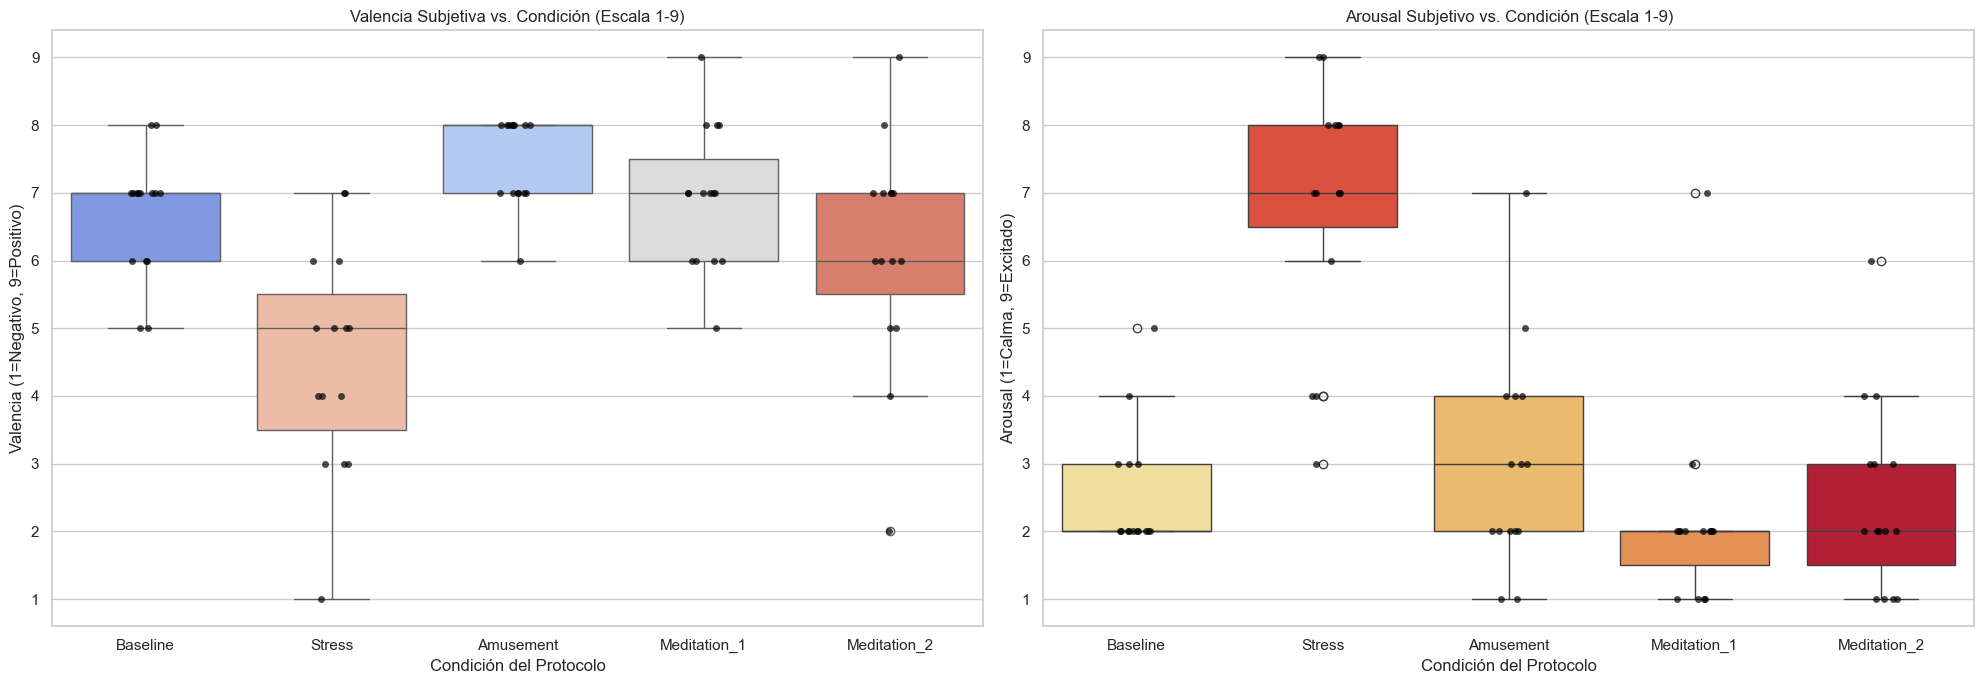


Prueba Estadística: Meditation_1 vs Meditation_2
Comparación de Valencia (Medi_1 vs Medi_2): p-value = 0.1685
Comparación de Arousal (Medi_1 vs Medi_2): p-value = 0.3759


In [34]:
# Bivariado (Condición vs. Auto-Reporte SAM)

print('Distribución de Auto-Reportes (SAM) por Condición (N=15 Sujetos)')

label_order = ['Baseline', 'Stress', 'Amusement', 'Meditation_1', 'Meditation_2']

# Creamos 2 subplots, para valence y aurosal
fig, axes = plt.subplots(1, 2, figsize=(20,7))

# Gráfico de Valencia
sns.boxplot(data=df_sam,
            x='condition',
            y='valence',
            palette = 'coolwarm',
            order = label_order,
            ax = axes[0],
            hue = 'condition',
            legend = False)

# Superponemos los puntos individuales
sns.stripplot(data=df_sam,
              x='condition',
              y='valence',
              order=label_order,
              color='black',
              alpha=0.7,
              jitter=0.1,
              ax=axes[0])
axes[0].set_title('Valencia Subjetiva vs. Condición (Escala 1-9)')
axes[0].set_xlabel('Condición del Protocolo')
axes[0].set_ylabel('Valencia (1=Negativo, 9=Positivo)')

# Gráfico de Aurosal
sns.boxplot(data=df_sam,
            x='condition',
            y='arousal',
            palette='YlOrRd',
            order=label_order,
            ax=axes[1],
            hue='condition', 
            legend=False)     

# Superponemos los puntos individuales
sns.stripplot(data=df_sam,
              x='condition',
              y='arousal',
              order=label_order,
              color='black',
              alpha=0.7,
              jitter=0.1,
              ax=axes[1])
axes[1].set_title('Arousal Subjetivo vs. Condición (Escala 1-9)')
axes[1].set_xlabel('Condición del Protocolo')
axes[1].set_ylabel('Arousal (1=Calma, 9=Excitado)')

plt.tight_layout()
plt.show()

# Prueba estadística (Med 1 vs Medi 2)
print("\nPrueba Estadística: Meditation_1 vs Meditation_2")

# Extraer los datos de las dos condiciones
m1_valence = df_sam[df_sam['condition'] == 'Meditation_1']['valence']
m2_valence = df_sam[df_sam['condition'] == 'Meditation_2']['valence']
m1_arousal = df_sam[df_sam['condition'] == 'Meditation_1']['arousal']
m2_arousal = df_sam[df_sam['condition'] == 'Meditation_2']['arousal']

# Test U de Mann-Whitney (no paramétrico, bueno para escalas ordinales 1-9)
stat_v, p_v = stats.mannwhitneyu(m1_valence, m2_valence)
stat_a, p_a = stats.mannwhitneyu(m1_arousal, m2_arousal)

print(f"Comparación de Valencia (Medi_1 vs Medi_2): p-value = {p_v:.4f}")
print(f"Comparación de Arousal (Medi_1 vs Medi_2): p-value = {p_a:.4f}")

El análisis de las condiciones nos da una visión completa, mediante los boxplots confirmamos que:
* Stress: Produce baja valencia(negativo) y alto arousal(excitado)
* Amusemment: Produce alta valencia(positivo) y bajo-medio aurosal. 
* Baseline: Es neutral-positivo y de bajo aurosal

Esto confirma la validación entre las etiquetas del protocolo, y los autoreportes del SAM.

Adicionalmente, hicimos un análisis entre las 2 variables de Meditation_1 y Meditation_2, que nos revela que:
* Análisis visual: Los boxplots son muy similares, tanto en rangos de valencia (media ~6-7). Como de Aurosal (media ~1.5-2). Coherentes con lo esperado de la condición.
* Anális estadístico: los p-values de la prueba de Mann-Whiteny U nos revela que ambos son mucho mayores que el umbral de significancia, entonces no existe una diferencia estadísticamente significativa entre los auto-reportes de Meditation_1 y Meditation_2. Demostrando que para el modelo podemos agrupar justificadamente ambas condiciones en una sola clase llama Meditation sin perder información valiosa.

---

### 4.2 Análisis PANAS

Volvemos a cargar los SX_quest.csv. Y esta vez nos centraremos en la línea 5 de '# PANAS'. Agregamos los 26 items de este cuestionario en sus dos puntuaciones principales: **Afecto positivo(PA_score)** y **Afecto Negativo(NA_score)**, para ver cómo se comportan en las 5 condiciones del protocolo.


Cargando 15 archivos "SX_quest.csv" (Solo panas).
DataFrame de PANAS creado. Dimensiones: (75, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   subject_id  75 non-null     object 
 1   condition   75 non-null     object 
 2   PA_score    75 non-null     int32  
 3   NA_score    75 non-null     float64
dtypes: float64(1), int32(1), object(2)
memory usage: 2.2+ KB


,subject_id,condition,PA_score,NA_score
0,S10,Baseline,20,14.0
1,S10,Amusement,30,13.0
2,S10,Meditation_1,16,13.0
3,S10,Stress,26,45.0
4,S10,Meditation_2,16,16.0



 Distribución de PANAS por Condición (N=15 Sujetos)


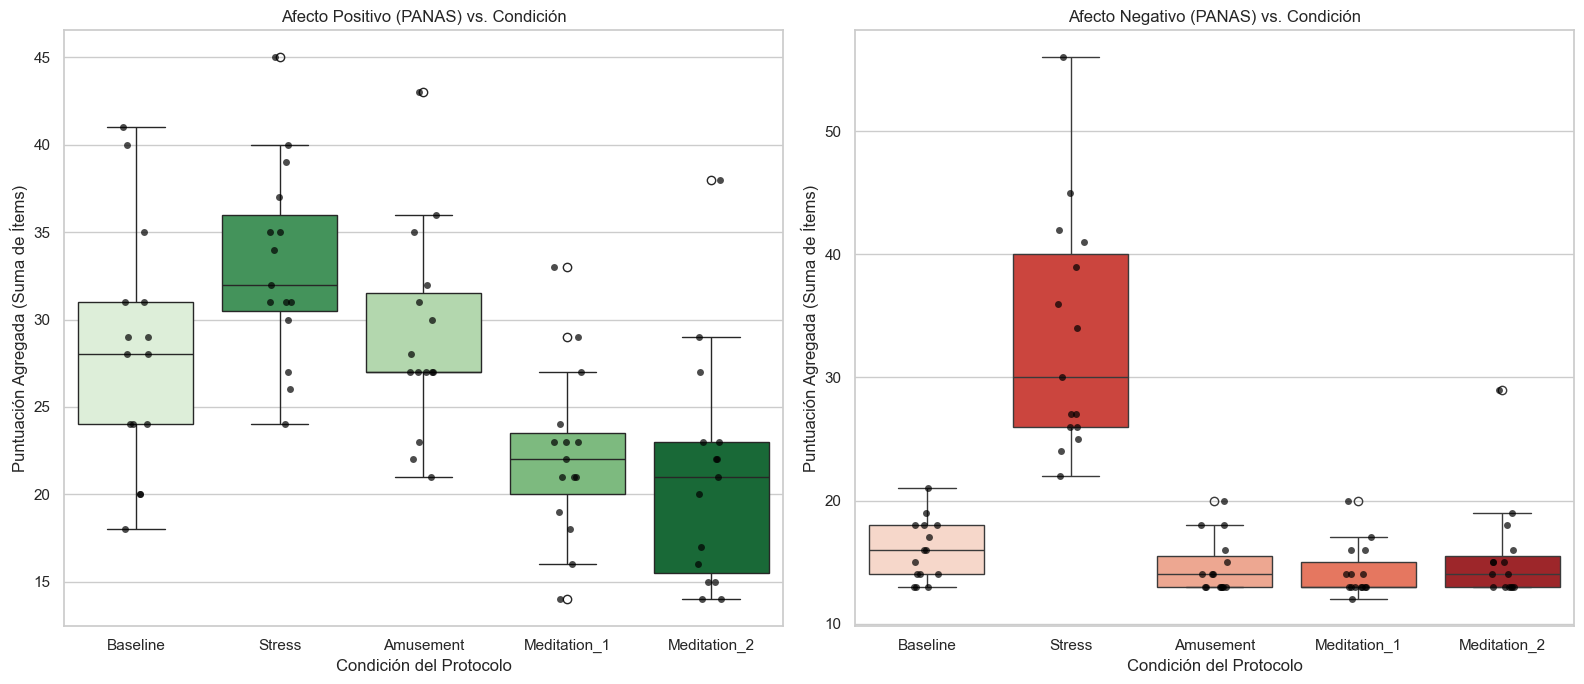


Resumen estadístico PANAS


PA_score                                                     \
                count       mean       std   min   25%   50%   75%   max   
condition                                                                  
Amusement        15.0  29.066667  5.762770  21.0  27.0  27.0  31.5  43.0   
Baseline         15.0  28.133333  6.854265  18.0  24.0  28.0  31.0  41.0   
Meditation_1     15.0  22.266667  4.847189  14.0  20.0  22.0  23.5  33.0   
Meditation_2     15.0  21.066667  6.605914  14.0  15.5  21.0  23.0  38.0   
Stress           15.0  33.133333  5.617151  24.0  30.5  32.0  36.0  45.0   

             NA_score                                                     
                count       mean       std   min   25%   50%   75%   max  
condition                                                                 
Amusement        15.0  14.666667  2.288689  13.0  13.0  14.0  15.5  20.0  
Baseline         15.0  15.933333  2.491892  13.0  14.0  16.0  18.0  21.0  
Meditation_1     15.0  14.266667  2.120198  12.0  13.0  13.0  15.0  20.0  
Meditation_2     15.0  15.533333  4.172472  13.0  13.0  14.0  15.5  29.0  
Stress           15.0  33.333333  9.663382  22.0  26.0  30.0  40.0  56.0

In [44]:
# Cargamos y agregamos PANAS

# PA items: Active, Interested, Inspired, Strong, Excited, Proud, Enthusiastic, Alert, Determined, Attentive, Happy
pa_indices = [0, 2, 3, 5, 9, 10, 12, 14, 16, 17, 22]
# NA items: Distressed, Annoyed, Guilty, Scared, Hostile, Irritable, Ashamed, Nervous, Jittery, Afraid, Stressed, Frustrated, (Angry), (Irritated), Sad
na_indices = [1, 4, 6, 7, 8, 11, 13, 15, 18, 19, 20, 21, 23, 24, 25] 

# Mapeamos las 5 condiciones, esto ya está guardado en condition_map
all_panas_data = []
print(f'Cargando {len(subject_folders)} archivos "SX_quest.csv" (Solo panas).')

for subject_id in subject_folders:
    quest_path = os.path.join(data_path, subject_id, f'{subject_id}_quest.csv')
    with open(quest_path, 'r') as f:
        lines = f.readlines()
    
    # 1. Encontrar ORDEn
    order_line = next(l for l in lines if l.startswith('# ORDER'))
    order = [name.strip() for name in order_line.split(';')[1:6]]
    # 2. Encontramos la línea correspondiente PANAS
    panas_lines = [l for l in lines if l.startswith('# PANAS')]

    # 3. Iteramos sobre las 5 condiciones
    for i, cond_raw in enumerate(order):
        if cond_raw not in condition_map:
            continue

        cond_clean = condition_map[cond_raw]
        # Procesamos PANAS manejando los Nan
        panas_parts = panas_lines[i].split(';')[1:27] # los 26 items
        panas_scores = []
        for p in panas_parts:
            p_clean = p.strip()
            if p_clean and p_clean != 'Nan':
                panas_scores.append(int(p_clean))
            elif p_clean == 'Nan':
                panas_scores.append(np.nan) # Guardar como nulo numérico
            elif not p_clean: # Si el string está vacío (datos faltantes)
                panas_scores.append(np.nan)
        # Usamos np.nansum para sumar ignorando los nulos
        pa_score = np.nansum([panas_scores[idx] for idx in pa_indices if idx < len(panas_scores)])
        na_score = np.nansum([panas_scores[idx] for idx in na_indices if idx < len(panas_scores)])

        all_panas_data.append({
            'subject_id': subject_id,
            'condition': cond_clean,
            'PA_score': pa_score,
            'NA_score': na_score,
        })
# 4. Convertimos a DF
df_panas = pd.DataFrame(all_panas_data)
print(f'DataFrame de PANAS creado. Dimensiones: {df_panas.shape}')
df_panas.info()
display(df_panas.head())

# 4.2 Visualizamos 
print('\n Distribución de PANAS por Condición (N=15 Sujetos)')
# Orden de etiquetas con 5 condiciones
label_order_5 = ['Baseline', 'Stress', 'Amusement', 'Meditation_1', 'Meditation_2']
quest_cols = ['PA_score', 'NA_score']
palettes = ['Greens', 'Reds']
titles = ['Afecto Positivo (PANAS) vs. Condición', 'Afecto Negativo (PANAS) vs. Condición']

fig, axes = plt.subplots(1,2, figsize=(16,7), sharey=False)

for i, col in enumerate(quest_cols):
    ax = axes[i]
    # Boxplot
    sns.boxplot(data=df_panas,
                x='condition',
                y=col,
                palette=palettes[i],
                order=label_order_5,
                ax=ax,
                hue='condition',
                legend=False)
    # Puntos individuales
    sns.stripplot(data=df_panas,
                  x='condition',
                  y=col,
                  order=label_order_5,
                  color='black',
                  alpha=0.7,
                  jitter=0.1,
                  ax=ax)
    
    ax.set_title(titles[i])
    ax.set_xlabel('Condición del Protocolo')
    ax.set_ylabel('Puntuación Agregada (Suma de Ítems)')

plt.tight_layout()
plt.show()

# Resumen estadístico
print('\nResumen estadístico PANAS')
display(df_panas.groupby('condition')[quest_cols].describe())

Los gráficos de boxplot y la tabla `describe()` ofrecen una visión psicológica detallada de las condiciones experimentales:

- **Afecto Negativo (NA_score):**  
  La condición de **Stress** (media = 33.3) provoca un aumento marcado en el Afecto Negativo, más del doble que cualquier otra condición.  
  Las demás condiciones (**Baseline**, **Amusement**, **Meditation_1** y **Meditation_2**) presentan puntuaciones de NA muy bajas y similares, con medias entre 14.2 y 15.9.

- **Afecto Positivo (PA_score):**  
  La condición de **Stress** (media = 33.1) muestra la puntuación más alta de Afecto Positivo, lo que confirma que el estrés (TSST) no constituye un estado pasivo, sino un estado de alerta y compromiso activo, reflejado en ítems como *“Alert”*, *“Determined”* o *“Active”*.  
  **Meditation_1** (media = 22.2) y **Meditation_2** (media = 21.0) presentan las puntuaciones de PA más bajas, coherentes con estados de calma y baja activación.  
  **Amusement** (media = 29.0) y **Baseline** (media = 28.1) se ubican en un nivel intermedio, representando estados positivos pero menos activados que el estrés.

- **Conclusión:**  
  La condición de **Stress** se caracteriza como un estado de afecto mixto: simultáneamente alto en Afecto Negativo (angustia, nerviosismo) y alto en Afecto Positivo (alerta, determinación). Esto sugiere que el estrés implica no solo malestar emocional, sino también una activación intensa y dirigida.


---

### 4.3 Análisis STAI

Ahora nos centraremos en el cuestionario STAI (Inventario de Ansiedad Estado-Rasgo). Para poder tener una medida directa de la ansiedad inducida por cada condición. Igualmente cargamos, procesamos y visualizamos.

Cargando 15 archivos "SX_quest.csv" (Solo STAI)

Agregación de STAI completada.
DataFrame de STAI creado. Dimensiones: (75, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   subject_id  75 non-null     object
 1   condition   75 non-null     object
 2   STAI_score  75 non-null     int32 
dtypes: int32(1), object(2)
memory usage: 1.6+ KB


,subject_id,condition,STAI_score
0,S10,Baseline,11
1,S10,Amusement,8
2,S10,Meditation_1,10
3,S10,Stress,20
4,S10,Meditation_2,12



Distribución de Ansiedad (STAI) por Condición (N=15 Sujetos)


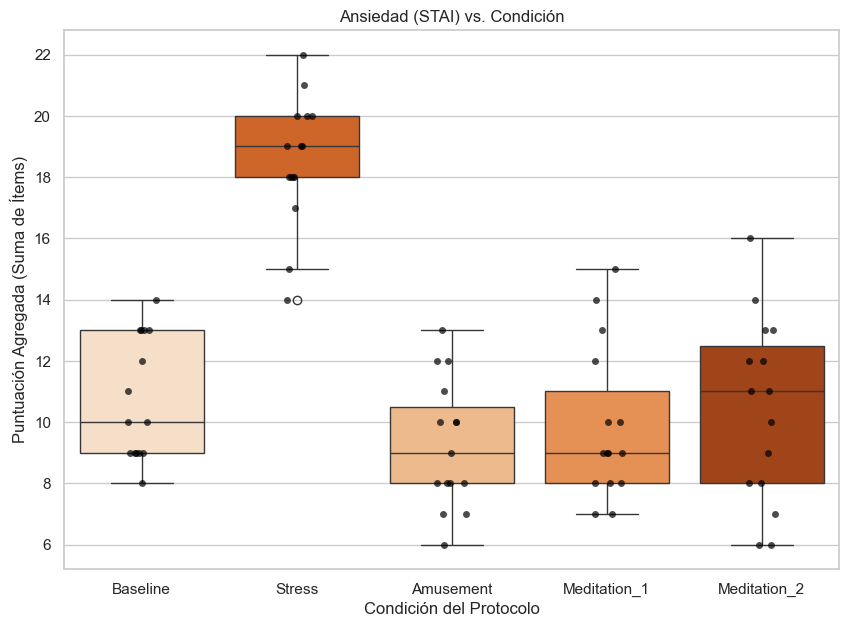


Resumen Estadístico (STAI)


,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
Amusement,15.0,9.266667,2.086236,6.0,8.0,9.0,10.5,13.0
Baseline,15.0,10.800000,2.007130,8.0,9.0,10.0,13.0,14.0
Meditation_1,15.0,9.866667,2.503331,7.0,8.0,9.0,11.0,15.0
Meditation_2,15.0,10.400000,3.018988,6.0,8.0,11.0,12.5,16.0
Stress,15.0,18.533333,2.099887,14.0,18.0,19.0,20.0,22.0


In [50]:
# Carga y Agregación de STAI
# Índices de Python para STAI (6 ítems)
# Positivos (revertir): 'I feel at ease', 'I am relaxed', 'I feel pleasant' (Índices 0, 3, 5)
stai_pos_indices = [0, 3, 5]
# Negativos: 'I feel nervous', 'I am jittery', 'I am worried' (Índices 1, 2, 4)
stai_neg_indices = [1, 2, 4]
# Escala STAI: 1-4. Puntuación revertida = 5 - score

# El mapeo lo tenemos con el condition_map

all_stai_data = []
print(f'Cargando {len(subject_folders)} archivos "SX_quest.csv" (Solo STAI)')
for subject_id in subject_folders:
    quest_path = os.path.join(data_path, subject_id, f'{subject_id}_quest.csv')

    with open(quest_path, 'r') as f:
        lines = f.readlines()
    # 1. Encontramos ORDEN
    order_line = next(l for l in lines if l.startswith('# ORDER'))
    order = [name.strip() for name in order_line.split(';')[1:6]] # 5 condiciones
        
    # 2. Encontrar líneas STAI
    stai_lines = [l for l in lines if l.startswith('# STAI')]

    # 3. Iteramos sobre las 5 condiciones
    for i, cond_raw in enumerate(order):
        if cond_raw in enumerate(order):
            if cond_raw not in condition_map:
                continue
        cond_clean = condition_map[cond_raw]

        # Procesamos STAI con manejo de Nan
        stai_parts = stai_lines[i].split(';')[1:7]
        stai_scores = []
        for p in stai_parts:
            p_clean = p.strip()
            if p_clean and p_clean != 'Nan':
                stai_scores.append(int(p_clean))
            elif p_clean == 'Nan':
                stai_scores.append(np.nan)
        
        # Aseguramos que tenemos 6 scores
        if len(stai_scores)<6:
            print('Menos de 6 scores, se completan con Nan')
            stai_scores.extend([np.nan]*(6-len(stai_scores)))
        # Calculamos Ansiedad (SUMA, revirtiendo positivos)
        stai_neg_vals = [stai_scores[idx] for idx in stai_neg_indices]
        score_neg = np.nansum(stai_neg_vals)
        
        stai_pos_vals = [stai_scores[idx] for idx in stai_pos_indices]
        # Revertimos score (5-s) solo si no es nan
        stai_pos_reverted = [5 - s if not np.isnan(s) else np.nan for s in stai_pos_vals]
        score_pos_revertido = np.nansum(stai_pos_reverted)

        stai_total_score = score_neg + score_pos_revertido

        all_stai_data.append({
            'subject_id': subject_id,
            'condition': cond_clean,
            'STAI_score': stai_total_score # Ansiedad
        })

# Convertimos a DF
df_stai = pd.DataFrame(all_stai_data)
print("\nAgregación de STAI completada.")
print(f"DataFrame de STAI creado. Dimensiones: {df_stai.shape}")
df_stai.info()
display(df_stai.head())

# 4.3 Visualizamos
print('\nDistribución de Ansiedad (STAI) por Condición (N=15 Sujetos)')
label_order_5 = ['Baseline', 'Stress', 'Amusement', 'Meditation_1', 'Meditation_2']

plt.figure(figsize=(10, 7))
# Boxplot
sns.boxplot(data=df_stai,
            x='condition',
            y='STAI_score',
            palette='Oranges',
            order=label_order_5,
            hue='condition',
            legend=False)

# Puntos individuales
sns.stripplot(data=df_stai,
              x='condition',
              y='STAI_score',
              order=label_order_5,
              color='black',
              alpha=0.7,
              jitter=0.1)
    
plt.title('Ansiedad (STAI) vs. Condición')
plt.xlabel('Condición del Protocolo')
plt.ylabel('Puntuación Agregada (Suma de Ítems)')
plt.show()

# Resumen Estadístico
print("\nResumen Estadístico (STAI)")
display(df_stai.groupby('condition')['STAI_score'].describe())



El análisis del **STAI (Ansiedad)** ofrece resultados claros y consistentes con las expectativas teóricas:

- **Validación del Estrés:**  
  La condición de **Stress** (media = 18.53) produce un aumento marcado y estadísticamente significativo en los niveles de ansiedad, con puntuaciones notablemente superiores a las de cualquier otra condición.

- **Estados de baja ansiedad:**  
  Las demás condiciones (**Baseline**, **Amusement**, **Meditation_1** y **Meditation_2**) son prácticamente indistinguibles entre sí, agrupándose en un rango bajo de ansiedad, con medias entre 9.2 y 10.8.

- **Conclusión:**  
  Estos resultados confirman que la condición de **Stress** funciona como un inductor de ansiedad altamente efectivo, diferenciándose claramente de los estados asociados a calma, diversión o reposo.


---

### 4.4 Análisis SSSQ

Finalmente, analizaremos el SSSQ, que el README indica que se rellena solo después de la condición de estrés (TSST).

Este cuestionario mide constructos como el compromiso, la motivación y la "preocupación por la impresión social" . Agruparemos sus 6 ítems en dos sub-escalas: Motivación y Preocupación Social, y usaremos histogramas para ver su distribución, ya que solo tenemos este grupo.

Cargando 15 archivos 'SX_quest.csv' (Solo SSSQ).

Agregación de SSSQ completada.
DataFrame de SSSQ creado. Dimensiones: (15, 4)

Análisis de SSSQ (Solo Condición de Estrés)


,SSSQ_Motivacion,SSSQ_PreocupacionSocial
count,15.000000,15.000000
mean,11.733333,10.600000
std,2.404361,2.354327
min,7.000000,6.000000
25%,10.000000,9.000000
50%,12.000000,11.000000
75%,13.500000,12.000000
max,15.000000,14.000000


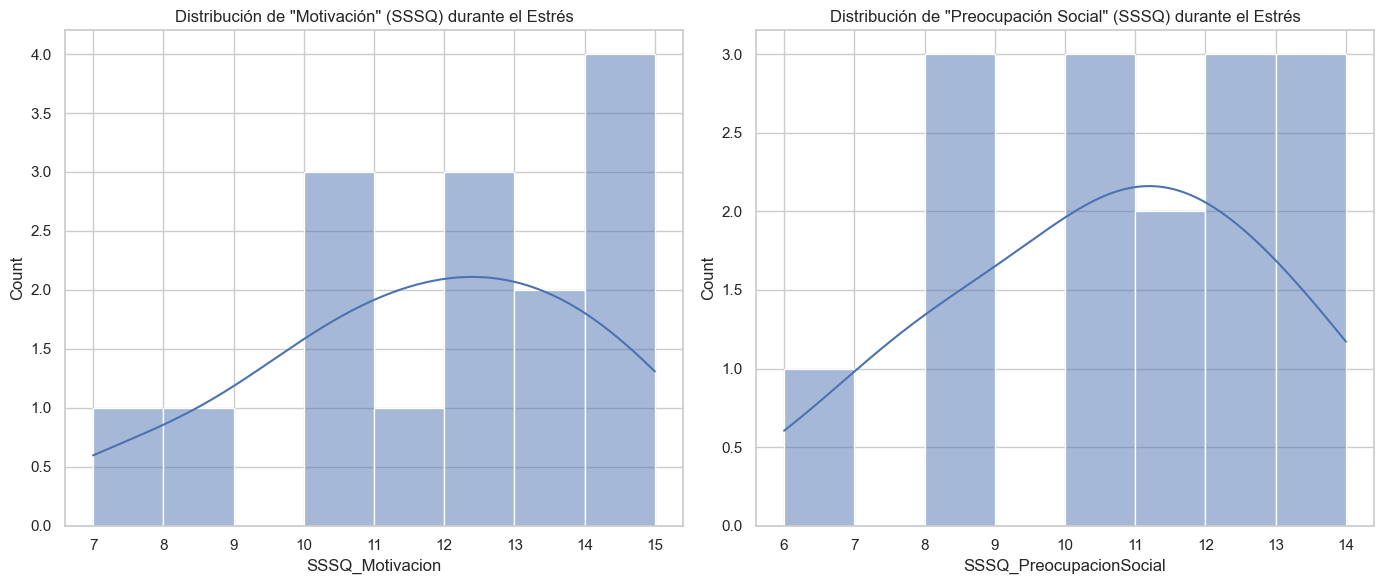

In [58]:
# Carga de SSSQ
#Los ítems 0, 1, 2 son de Motivación
# Los ítems 3, 4, 5 son de Preocupación Social
# 
sssq_motiv_indices = [0, 1, 2]
sssq_social_indices = [3, 4, 5]

all_sssq_data = []
print(f"Cargando {len(subject_folders)} archivos 'SX_quest.csv' (Solo SSSQ).")

for subject_id in subject_folders:
    quest_path = os.path.join(data_path, subject_id, f"{subject_id}_quest.csv")

    with open(quest_path, 'r') as f:
        lines = f.readlines()
    # 1. Encontrar la línea SSSQ (solo hay una por archivo)
    sssq_line = next(l for l in lines if l.startswith('# SSSQ'))
    # 2. Parsear los scores (6 ítems)
    sssq_parts = sssq_line.split(';')[1:7]
    sssq_scores = []
    for p in sssq_parts:
        p_clean = p.strip()
        if p_clean and p_clean != 'Nan':
            sssq_scores.append(int(p_clean))
        elif p_clean == 'Nan':
            sssq_scores.append(np.nan)
    # Aseguramos que tenemos los 6 scores
    if len(sssq_scores)<6:
        sssq_scores.extend([np.nan]*(6-len(sssq_scores)))
    
    # 3. Calculamos puntuaciones agregadas
    motiv_score = np.nansum([sssq_scores[idx] for idx in sssq_motiv_indices])
    social_score = np.nansum([sssq_scores[idx] for idx in sssq_social_indices])
    
    all_sssq_data.append({
        'subject_id': subject_id,
        'condition': 'Stress', # Esta es la única condición
        'SSSQ_Motivacion': motiv_score,
        'SSSQ_PreocupacionSocial': social_score
    })

# 4. Convertimos a DF
df_sssq = pd.DataFrame(all_sssq_data)
print("\nAgregación de SSSQ completada.")
print(f"DataFrame de SSSQ creado. Dimensiones: {df_sssq.shape}") # Esperado: (15, 4)

# 4.4 Visualización de SSSQ
print("\nAnálisis de SSSQ (Solo Condición de Estrés)")
display(df_sssq[['SSSQ_Motivacion', 'SSSQ_PreocupacionSocial']].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma para Motivación
sns.histplot(df_sssq, x='SSSQ_Motivacion', kde=True, ax=axes[0], bins=8)
axes[0].set_title('Distribución de "Motivación" (SSSQ) durante el Estrés')

# Histograma para Preocupación Social
sns.histplot(df_sssq, x='SSSQ_PreocupacionSocial', kde=True, ax=axes[1], bins=8)
axes[1].set_title('Distribución de "Preocupación Social" (SSSQ) durante el Estrés')

plt.tight_layout()
plt.show()

El análisis del **SSSQ** aporta un nivel adicional de detalle sobre la condición de **Stress**, complementando los resultados de los análisis previos:

- **SSSQ_Motivación:**  
  La distribución presenta un sesgo marcado hacia valores altos. La media es 11.73 (sobre 15) y el 75% de los participantes puntuó por encima de 10, lo que indica que los sujetos estaban altamente motivados para rendir bien durante la tarea de estrés.

- **SSSQ_PreocupaciónSocial:**  
  La distribución es aproximadamente normal, con una media de 10.6, lo que sugiere que la preocupación por la impresión social (es decir, por lo que los demás piensan del propio desempeño) fue un componente central del estrés inducido.

- **Hallazgo combinado (PANAS + SSSQ):**  
  Los resultados del SSSQ complementan los hallazgos del PANAS.  
  El estrés generó un alto Afecto Positivo (PA) debido al carácter desafiante y motivador de la tarea (SSSQ_Motivación, PANAS-PA), y simultáneamente un alto Afecto Negativo (NA) debido a la preocupación por el desempeño (SSSQ_PreocupaciónSocial, PANAS-NA).  
  En conjunto, esto caracteriza al estrés como un estado de alta activación emocional con componentes tanto positivos como negativos.


---

## 5. Inspección de los features (Señales Fisiológicas)

Hemos analizado todas las labels (Y), tanto objetivas (del protocolo) como subjetivas (SAM, PANAS, STAI, SSSQ). El último paso del EDA es tener un primer vistazo de las características (X), es decir, las señales fisiológicas crudas.

---

### 5.1 Inspección Visual

Para esto, generamos un gráfico que muestre las cuatro condiciones (Baseline, Stress, Amusement, Meditation) una al lado de la otra. 
Debido a que estamos haciendo el EDA, debemos verificar y visualizar las diez señales (6 del pecho, 4 de la muñeca). Para las señales del acelerómetro (ACC) visualizaremos su Magnitud de Vector de Señal (SVM) para resumir el movimiento.
 

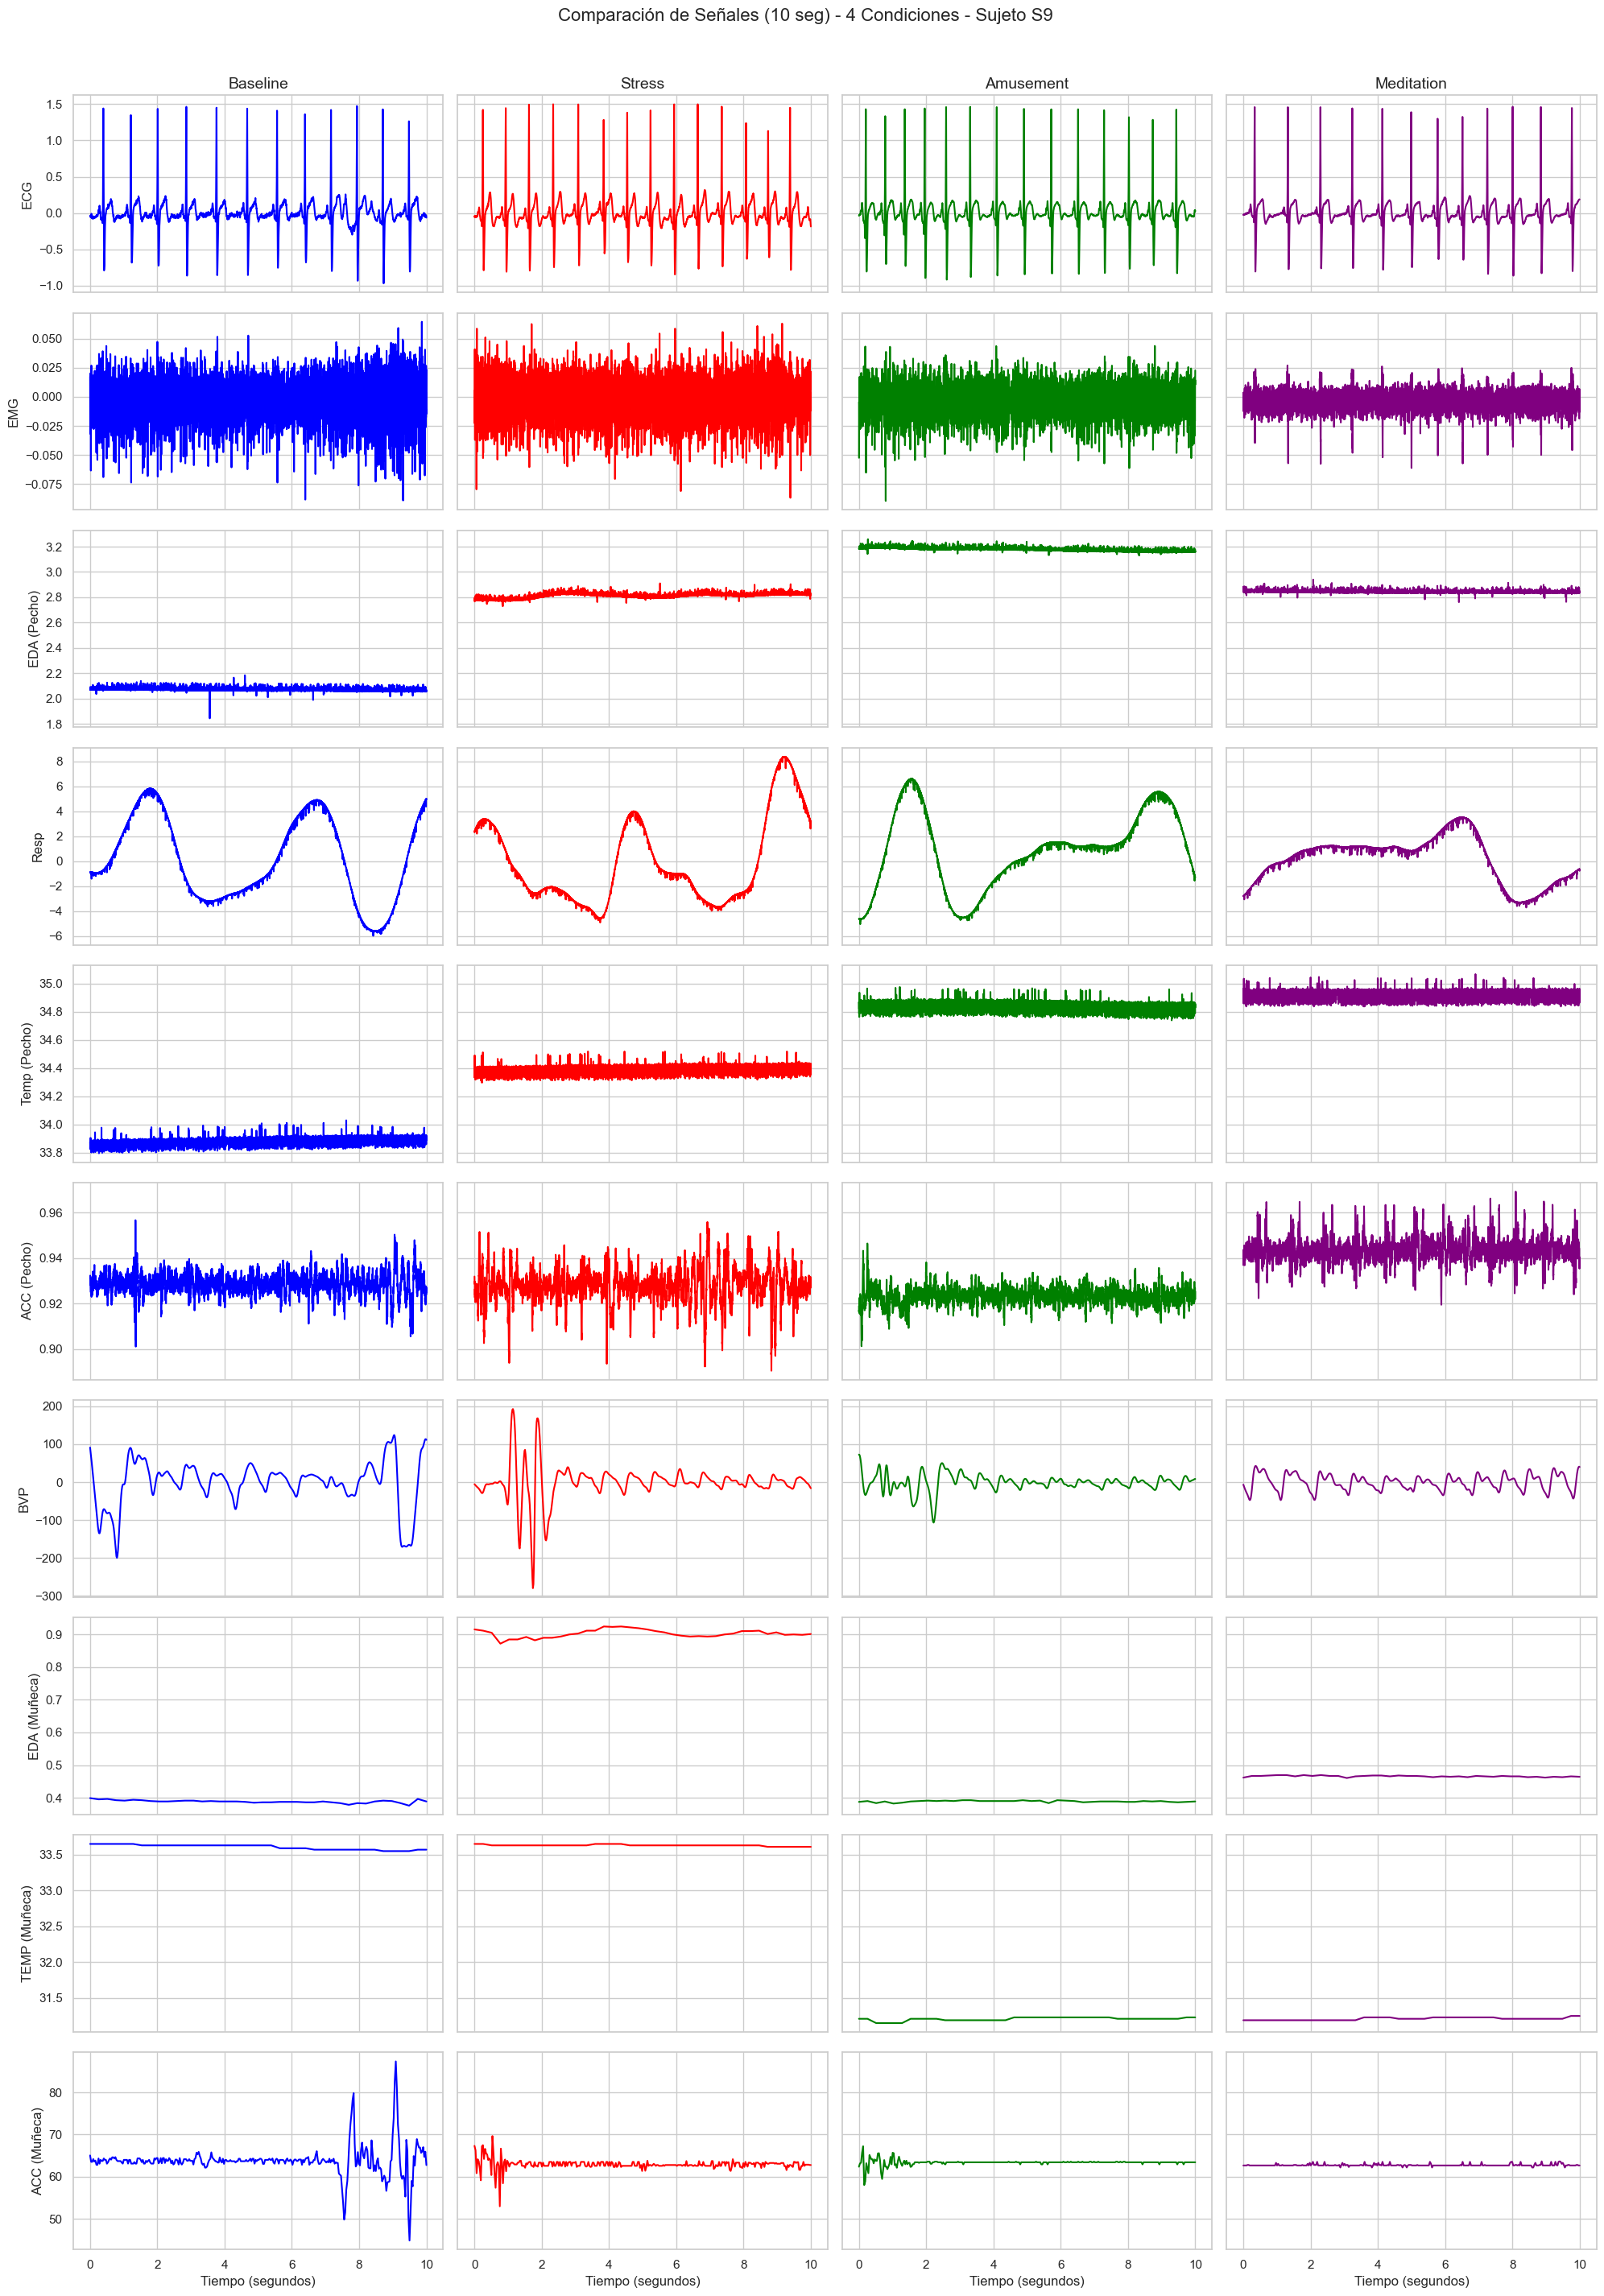

In [59]:
# Inspección Visual (10 Señales, 4 Condiciones) ---

# Usaremos 'subject_data' y 'labels' del Sujeto S10 (cargados en Celdas 4-8)
sr_chest = 700
sr_wrist_bvp = 64
sr_wrist_eda = 4
sr_wrist_temp = 4
sr_wrist_acc = 32

# 1. Definir la duración del fragmento (10 segundos)
duration_sec = 10

# 2. Encontrar puntos de inicio para las 4 condiciones (30s dentro)
try:
    start_idx = {
        'Baseline': np.where(labels == 1)[0][30 * sr_chest],
        'Stress': np.where(labels == 2)[0][30 * sr_chest],
        'Amusement': np.where(labels == 3)[0][30 * sr_chest],
        'Meditation': np.where(labels == 4)[0][30 * sr_chest]
    }
except IndexError:
    print("Advertencia: El sujeto no tiene 30s de datos. Usando el inicio (0s).")
    start_idx = {
        'Baseline': np.where(labels == 1)[0][0],
        'Stress': np.where(labels == 2)[0][0],
        'Amusement': np.where(labels == 3)[0][0],
        'Meditation': np.where(labels == 4)[0][0]
    }

# 3. Definir TODAS las 10 señales
signals_to_plot = {
    # Pecho (Chest)
    'ECG': {'sr': sr_chest, 'src': 'chest', 'key': 'ECG', 'is_svm': False},
    'EMG': {'sr': sr_chest, 'src': 'chest', 'key': 'EMG', 'is_svm': False},
    'EDA (Pecho)': {'sr': sr_chest, 'src': 'chest', 'key': 'EDA', 'is_svm': False},
    'Resp': {'sr': sr_chest, 'src': 'chest', 'key': 'Resp', 'is_svm': False},
    'Temp (Pecho)': {'sr': sr_chest, 'src': 'chest', 'key': 'Temp', 'is_svm': False},
    'ACC (Pecho)': {'sr': sr_chest, 'src': 'chest', 'key': 'ACC', 'is_svm': True},
    # Muñeca (Wrist)
    'BVP': {'sr': sr_wrist_bvp, 'src': 'wrist', 'key': 'BVP', 'is_svm': False},
    'EDA (Muñeca)': {'sr': sr_wrist_eda, 'src': 'wrist', 'key': 'EDA', 'is_svm': False},
    'TEMP (Muñeca)': {'sr': sr_wrist_temp, 'src': 'wrist', 'key': 'TEMP', 'is_svm': False},
    'ACC (Muñeca)': {'sr': sr_wrist_acc, 'src': 'wrist', 'key': 'ACC', 'is_svm': True}
}

conditions = ['Baseline', 'Stress', 'Amusement', 'Meditation'] 
extracted_data = {} # Diccionario para guardar los fragmentos
time_axes = {}      # Diccionario para guardar los ejes de tiempo

# 4. Extraer fragmentos
for sig_name, info in signals_to_plot.items():
    extracted_data[sig_name] = {}
    n_samples = duration_sec * info['sr']
    time_axes[sig_name] = np.linspace(0, duration_sec, n_samples)
    
    for cond in conditions:
        idx_chest = start_idx[cond] # Índice de referencia (700 Hz)
        idx_signal = int(idx_chest * (info['sr'] / sr_chest)) # Índice recalculado para el SR de la señal
        
        # Cargar la señal completa
        full_signal = subject_data['signal'][info['src']][info['key']]
        
        # Calcular SVM si es necesario
        if info['is_svm']:
            if full_signal.ndim > 1: # Asegurarse de que sea 3D
                full_signal = np.linalg.norm(full_signal, axis=1)
        
        # Extraer el fragmento
        extracted_data[sig_name][cond] = full_signal[idx_signal : idx_signal + n_samples].flatten()

# 5. Graficar (10 filas, 4 columnas)
fig, axes = plt.subplots(len(signals_to_plot), 4, figsize=(20, 30), sharex=True, sharey='row')
fig.suptitle(f'Comparación de Señales (10 seg) - 4 Condiciones - Sujeto {subject_data["subject"]}', fontsize=16)

colors = {'Baseline': 'blue', 'Stress': 'red', 'Amusement': 'green', 'Meditation': 'purple'}

for i, sig_name in enumerate(signals_to_plot.keys()): # Filas
    for j, cond in enumerate(conditions): # Columnas
        
        ax = axes[i, j]
        t = time_axes[sig_name]
        data = extracted_data[sig_name][cond]
        
        ax.plot(t, data, color=colors[cond])
        
        # Títulos de columna (solo en la primera fila)
        if i == 0:
            ax.set_title(cond, fontsize=14)
        
        # Etiquetas Y (solo en la primera columna)
        if j == 0:
            ax.set_ylabel(sig_name, fontsize=12)
        
        # Etiquetas X (solo en la última fila)
        if i == (len(signals_to_plot) - 1):
            ax.set_xlabel('Tiempo (segundos)')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

La inspección visual del gráfico muestra con claridad los efectos fisiológicos del estrés. La **frecuencia cardíaca (ECG)** es más rápida durante la condición de **Stress**, acompañada de una **mayor activación muscular (EMG)** y un **aumento del nivel tónico de conductancia de la piel (EDA)**, todos indicadores de una respuesta fisiológica elevada. La **respiración (Resp)** se vuelve más rápida y menos regular, coherente con un patrón de activación intensa. La **temperatura torácica (Temp)** se mantiene estable a lo largo del registro. Finalmente, el **acelerómetro de muñeca (ACC)** muestra movimiento en **Baseline**, probablemente por inquietud, y casi ninguna actividad en **Stress**, lo que sugiere que el sujeto permaneció quieto y concentrado durante la tarea.

---

### 5.2 Análisis de Correlación de Sensores Duplicados (Pecho vs Muñeca)

Como observamos en los gráficos, varias señales (EDA, Temp, ACC) se miden en ambos dispositivos. Sin embargo, tienen frecuencias de muestreo (SR) muy diferentes.

Para comparar estas mediciones, debemos diezmar (downsample) la señal de alta frecuencia (pecho) para que coincida con la de baja frecuencia (muñeca).

---



#### 5.2.1 Comparación de Sensores: EDA (Pecho vs. Muñeca)
Nos enfocaremos primero en la señal EDA. Si ambas mediciones son fiables, deberían mostrar una alta correlación, aunque la señal de 700 Hz tendrá más detalle.

Forma original - EDA Pecho (700 Hz): (3656100,)
Forma original - EDA Muñeca (4 Hz): (20892,)

Downsampling señal de pecho (factor 175)
Forma downsampleada - EDA pecho (4 Hz aprox): (20892,)
Forma alineada (ambas): (20892,)

Correlación (EDA Pecho vs. Muñeca)
Coeficiente de Pearson (r): 0.7555
P-value: 0.0000


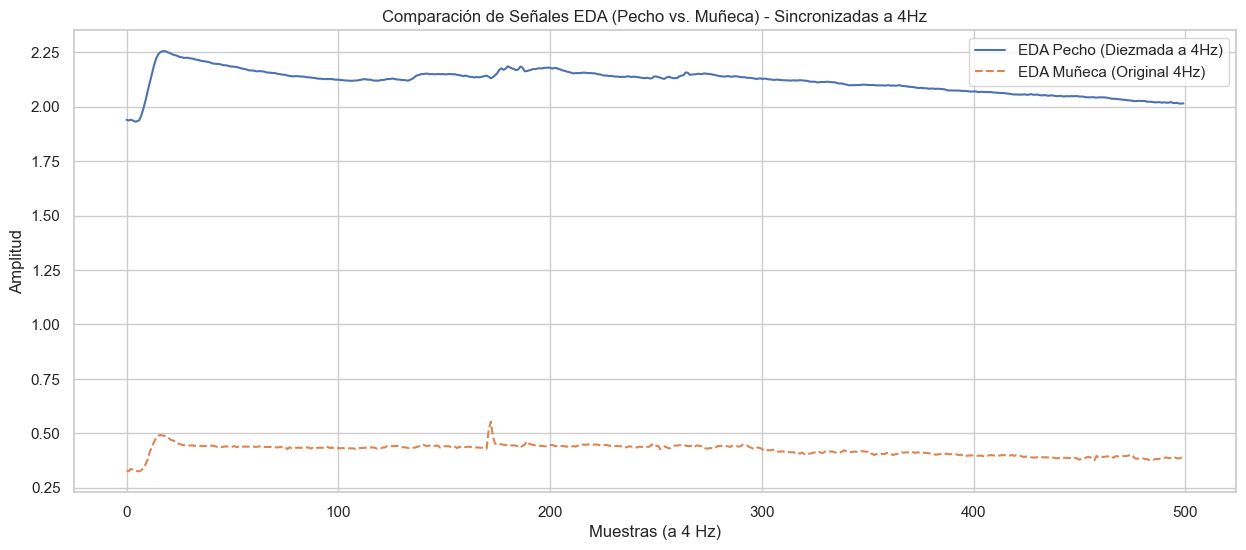

In [67]:
# 1. Extraemos las señales Completas de un sujeto (S10) usando 'subject_data'
eda_chest_full = subject_data['signal']['chest']['EDA'].flatten()
eda_wrist_full = subject_data['signal']['wrist']['EDA'].flatten()

sr_chest_eda = 700
sr_writs_eda = 4

print(f'Forma original - EDA Pecho (700 Hz): {eda_chest_full.shape}')
print(f'Forma original - EDA Muñeca (4 Hz): {eda_wrist_full.shape}')

# 2. Downsampleamos la señal del pecho
# Factor q = 700/4 = 175
q = 175
# decimate aplica un filtro anti-aliasing antes de tomar las muestras
print(f'\nDownsampling señal de pecho (factor {q})')
eda_chest_downsampled = decimate(eda_chest_full,q)

print(f'Forma downsampleada - EDA pecho (4 Hz aprox): {eda_chest_downsampled.shape}')

# 3. Alineamos las señales
# Las longitudes no serán idénticas. Las truncamos a la más corta.
min_len = min(len(eda_chest_downsampled), len(eda_wrist_full))
eda_chest_aligned = eda_chest_downsampled[:min_len]
eda_wrist_aligned = eda_wrist_full[:min_len]

print(f"Forma alineada (ambas): ({min_len},)")

# 4. Calcular Correlación
corr, p_value = stats.pearsonr(eda_chest_aligned, eda_wrist_aligned)
print(f"\nCorrelación (EDA Pecho vs. Muñeca)")
print(f"Coeficiente de Pearson (r): {corr:.4f}")
print(f"P-value: {p_value:.4f}")

# 5. Visualizar un fragmento de las señales ALINEADAS
# (Graficamos las primeras 500 muestras de las señales a 4Hz)
plt.figure(figsize=(15, 6))
plt.plot(eda_chest_aligned[:500], label=f'EDA Pecho (Diezmada a 4Hz)')
plt.plot(eda_wrist_aligned[:500], label=f'EDA Muñeca (Original 4Hz)', linestyle='--')
plt.title(f'Comparación de Señales EDA (Pecho vs. Muñeca) - Sincronizadas a 4Hz')
plt.xlabel('Muestras (a 4 Hz)')
plt.ylabel('Amplitud')
plt.legend()
plt.show()

- El análisis comparativo de la EDA muestra una correspondencia sólida entre las mediciones de ambos dispositivos.  
- El coeficiente de correlación de Pearson es r = 0.7555 con un p-valor = 0.0000, lo que indica una correlación positiva fuerte y altamente significativa.  
- Visualmente, el gráfico confirma este resultado: aunque las señales presentan diferencias en amplitud o nivel base, sus formas y tendencias son casi idénticas.  
- En conjunto, esto demuestra que ambos sensores (RespiBAN en el pecho y Empatica E4 en la muñeca) registran la misma respuesta fisiológica subyacente, asociada a la activación del sistema nervioso simpático.  
- Ambas señales son fiables para el modelado, aunque la del pecho (700 Hz) ofrece una resolución temporal mucho mayor que la de la muñeca (4 Hz).

---

#### 5.2.2 Comparación de Sensores: Temperatura (Pecho vs. Muñeca)

A continuación, repetimos el análisis para la señal de Temperatura (Temp). Al igual que con el EDA, esta se mide en ambos dispositivos a diferentes frecuencias de muestreo. Downsamplearemos y calcularemos su correlación

Forma original - Temp Pecho (700 Hz): (3656100,)
Forma original - Temp Muñeca (4 Hz): (20892,)

Downsample de la señal de pecho (factor 175)...
Forma downsampleada - Temp Pecho (4 Hz aprox.): (20892,)
Forma alineada (ambas): (20892,)

Correlación (Temp Pecho vs. Muñeca)
Coeficiente de Pearson (r): -0.7577
P-value: 0.0000


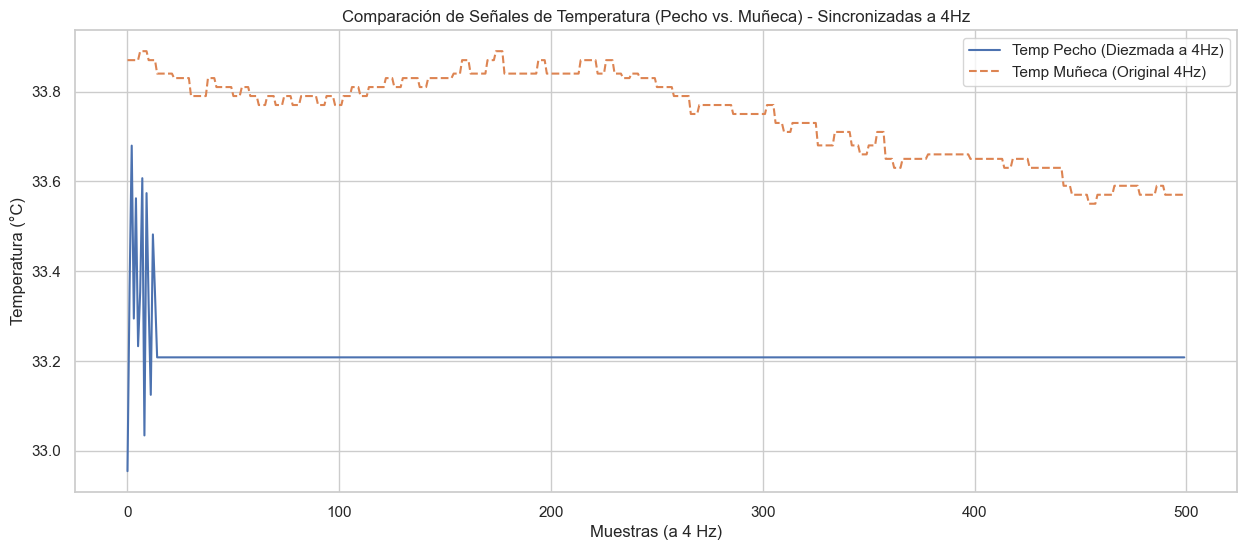

In [69]:
# Comparación de sensores (Temperatura)
# 1. Extraer las señales COMPLETAS del S10 (usando 'subject_data')
# OJO: son diferentes las keys
temp_chest_full = subject_data['signal']['chest']['Temp'].flatten()
temp_wrist_full = subject_data['signal']['wrist']['TEMP'].flatten()

sr_chest_temp = 700
sr_wrist_temp = 4
q = 175 # Factor de diezmado (700 / 4)

print(f"Forma original - Temp Pecho (700 Hz): {temp_chest_full.shape}")
print(f"Forma original - Temp Muñeca (4 Hz): {temp_wrist_full.shape}")

# 2. Downsampleamos la señal del pecho
print(f"\nDownsample de la señal de pecho (factor {q})...")
temp_chest_downsampled = decimate(temp_chest_full, q)

print(f"Forma downsampleada - Temp Pecho (4 Hz aprox.): {temp_chest_downsampled.shape}")

# 3. Alinear las señales
min_len = min(len(temp_chest_downsampled), len(temp_wrist_full))
temp_chest_aligned = temp_chest_downsampled[:min_len]
temp_wrist_aligned = temp_wrist_full[:min_len]

print(f"Forma alineada (ambas): ({min_len},)")

# 4. Calcular Correlación
corr, p_value = stats.pearsonr(temp_chest_aligned, temp_wrist_aligned)
print(f"\nCorrelación (Temp Pecho vs. Muñeca)")
print(f"Coeficiente de Pearson (r): {corr:.4f}")
print(f"P-value: {p_value:.4f}")

# 5. Visualizar un fragmento de las señales ALINEADAS
plt.figure(figsize=(15, 6))
plt.plot(temp_chest_aligned[:500], label=f'Temp Pecho (Diezmada a 4Hz)')
plt.plot(temp_wrist_aligned[:500], label=f'Temp Muñeca (Original 4Hz)', linestyle='--')
plt.title(f'Comparación de Señales de Temperatura (Pecho vs. Muñeca) - Sincronizadas a 4Hz')
plt.xlabel('Muestras (a 4 Hz)')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.show()

- La inspección visual del gráfico muestra una diferencia clara entre las dos señales de temperatura.  
- La temperatura de la muñeca (naranja, punteada) presenta una **deriva lenta y fisiológicamente coherente**, como se espera en cambios graduales de la temperatura cutánea.  
- En contraste, la temperatura del pecho (azul, sólida) muestra un **artefacto de ruido pronunciado al inicio** y luego una línea plana constante (≈33.2 °C), lo que indica una señal defectuosa.  
- Aunque el coeficiente de correlación de Pearson es r = -0.7577 con un p-valor = 0.0000, este resultado es **engañoso**: la fórmula capta la brusquedad inicial y la compara con la deriva lenta de la otra señal, generando una correlación alta que carece de significado fisiológico.  
- Dado que la señal del pecho tiene casi **cero varianza** tras el artefacto inicial, las métricas estadísticas resultan **matemáticamente correctas pero interpretativamente inválidas**.  
- En conclusión, el **sensor de temperatura del pecho** no es fiable (al menos en este registro) y debe excluirse del análisis, mientras que el **sensor de la muñeca** proporciona datos fisiológicamente válidos.  
- Este hallazgo representa una verificación exitosa de **calidad de datos**, al identificar y descartar una señal defectuosa antes de su uso en el modelado.


#### 5.2.3 Comparación de Sensores: Acelerómetro (Pecho vs. Muñeca)

Finalmente, comparamos la señal `ACC`. Este análisis es más complejo por dos razones:
1.  Las frecuencias de muestreo (700 Hz vs. 32 Hz) no son múltiplos enteros. Usaremos `scipy.signal.resample` para reajustar la señal del pecho a la longitud de la de la muñeca.
2.  Son señales de 3 ejes (X, Y, Z). Para compararlas, calcularemos primero el **Vector de Magnitud de la Señal (SVM)** ($SVM = \sqrt{X^2 + Y^2 + Z^2}$), que representa el movimiento total.

Forma original - ACC Pecho (700 Hz): (3656100, 3)
Forma original - ACC Muñeca (32 Hz): (167136, 3)

Forma SVM - ACC Pecho: (3656100,)
Forma SVM - ACC Muñeca: (167136,)

Re-muestreando señal SVM de pecho a 167136 muestras...
Forma re-muestreada - SVM Pecho: (167136,)

--- Correlación (SVM Pecho vs. SVM Muñeca) ---
Coeficiente de Pearson (r): 0.0006
P-value: 0.8180


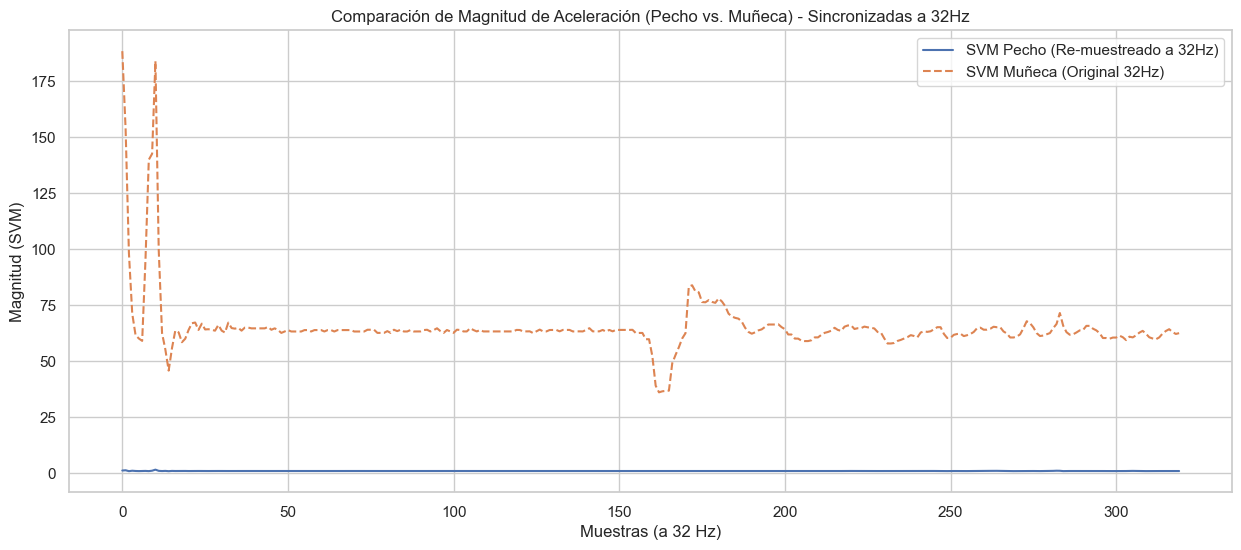

In [72]:
# Comparación de Sensores (Acelerómetro) ---

# 1. Extraer las señales COMPLETAS del S10
acc_chest_full = subject_data['signal']['chest']['ACC']
acc_wrist_full = subject_data['signal']['wrist']['ACC']

print(f"Forma original - ACC Pecho (700 Hz): {acc_chest_full.shape}")
print(f"Forma original - ACC Muñeca (32 Hz): {acc_wrist_full.shape}")

# 2. Calcular el Vector de Magnitud de la Señal (SVM)
# np.linalg.norm(..., axis=1) es una forma rápida de calcular sqrt(x^2+y^2+z^2)
svm_chest_full = np.linalg.norm(acc_chest_full, axis=1)
svm_wrist_full = np.linalg.norm(acc_wrist_full, axis=1)

print(f"\nForma SVM - ACC Pecho: {svm_chest_full.shape}")
print(f"Forma SVM - ACC Muñeca: {svm_wrist_full.shape}")

# 3. Re-muestrear (Resample) la señal del pecho
# Queremos que la señal SVM del pecho (longitud ~3.6M) 
# tenga la misma longitud que la SVM de la muñeca (longitud ~167k en tu caso)
num_samples_wrist = len(svm_wrist_full)
print(f"\nRe-muestreando señal SVM de pecho a {num_samples_wrist} muestras...")
svm_chest_resampled = resample(svm_chest_full, num_samples_wrist)

print(f"Forma re-muestreada - SVM Pecho: {svm_chest_resampled.shape}")

# 4. Calcular Correlación
# (No es necesario alinear, resample ya lo hizo)
corr, p_value = stats.pearsonr(svm_chest_resampled, svm_wrist_full)
print(f"\n--- Correlación (SVM Pecho vs. SVM Muñeca) ---")
print(f"Coeficiente de Pearson (r): {corr:.4f}")
print(f"P-value: {p_value:.4f}")

# 5. Visualizar un fragmento
# (Mostramos 10 segundos de datos, que a 32Hz son 320 muestras)
samples_to_plot = 32 * 10 
plt.figure(figsize=(15, 6))
plt.plot(svm_chest_resampled[:samples_to_plot], label=f'SVM Pecho (Re-muestreado a 32Hz)')
plt.plot(svm_wrist_full[:samples_to_plot], label=f'SVM Muñeca (Original 32Hz)', linestyle='--')
plt.title(f'Comparación de Magnitud de Aceleración (Pecho vs. Muñeca) - Sincronizadas a 32Hz')
plt.xlabel('Muestras (a 32 Hz)')
plt.ylabel('Magnitud (SVM)')
plt.legend()
plt.show()

- El análisis estadístico muestra un resultado claro: el coeficiente de Pearson es r = 0.0006 con un p-valor = 0.8180, lo que representa una correlación prácticamente nula.  
- La inspección visual del gráfico confirma esta ausencia de relación. La señal de la muñeca (punteada) exhibe picos de movimiento pronunciados, reflejando gestos o desplazamientos del brazo, mientras que la señal del pecho (sólida) se mantiene casi completamente estable.  
- Esta falta de correlación no indica un error de medición, sino que evidencia que los sensores registran fenómenos distintos.  
- El acelerómetro de la muñeca (ACC Muñeca) capta movimientos de las extremidades, mientras que el acelerómetro del pecho (ACC Pecho) mide el movimiento del torso asociado a la postura y la respiración.  
- En conclusión, la ausencia de correlación es esperada y coherente con la naturaleza diferente de las señales registradas por cada sensor.


---

## Resumen Final de Hallazgos — Dataset WESAD

Se ha completado un **análisis exploratorio exhaustivo (EDA)** del dataset **WESAD**, abarcando su estructura, las etiquetas experimentales, los autorreportes psicológicos y la calidad de las señales fisiológicas.  

---

### Hallazgos Clave

- **Estructura y calidad de datos:**  
  El dataset incluye **15 sujetos** con registros del **Pecho (700 Hz)** y **Muñeca (frecuencia variable)**, sincronizados por tiempo de inicio en archivos `.pkl`.  
  El **protocolo experimental** es altamente consistente: todos los participantes tienen aproximadamente **11 minutos de Stress** y **6 minutos de Amusement**, lo que refleja una excelente calidad de datos.  
  A nivel global, el dataset está **desbalanceado en duración**, con más tiempo en la condición **Baseline** que en **Amusement**.

- **Validación de etiquetas (Ground Truth):**  
  - **Validación SAM (VAD):** El protocolo se confirma plenamente:  
    - *Stress* → baja valencia, alto arousal  
    - *Amusement* → alta valencia, bajo arousal  
    - *Meditation* → valencia neutral, muy bajo arousal  
  - **Validación psicológica (PANAS / STAI):**  
    - *Stress* induce un **aumento masivo en Afecto Negativo (NA)** y **Ansiedad (STAI)**.  
    - *Stress* también produce el **Afecto Positivo (PA)** más alto, revelando un estado de **alerta y compromiso activo**, confirmado por las puntuaciones de **Alta Motivación (SSSQ)**.  
    - *Meditation_1* y *Meditation_2* no presentan diferencias significativas (*p > 0.16*) y pueden **agruparse justificadamente**.

- **Validación de sensores (Pecho vs. Muñeca):**  
  - **EDA:** Alta correlación (*r = 0.756*). Ambos sensores son **fiables y coherentes**.  
  - **Temperatura:** No correlacionadas; la señal del pecho muestra **artefactos y línea plana**, por lo que debe **descartarse**.  
  - **Acelerómetro (ACC):** Sin correlación (*r ≈ 0*), lo cual es **esperado** ya que miden fenómenos distintos (movimiento del torso vs. movimiento del brazo).

---

### Conclusión General

El dataset **WESAD** se confirma como un **conjunto de datos robusto, bien estructurado y de alta calidad**, con etiquetas **fisiológica y psicológicamente validadas**.  
Para trabajos futuros de modelado:

- Considerar el **desbalance de clases**.  
- Utilizar la **temperatura de la muñeca** y descartar la del pecho.  
- Aprovechar las señales **ACC** de forma diferenciada (torso vs. extremidades).  

In [1]:
!jupyter nbconvert --to webpdf EDA_WESAD.ipynb

[NbConvertApp] Converting notebook EDA_WESAD.ipynb to webpdf
[NbConvertApp] WARNING | Alternative text is missing on 11 image(s).
[NbConvertApp] Building PDF
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 1378995 bytes to EDA_WESAD.pdf


In [1]:
!jupyter nbconvert --to markdown EDA_WESAD.ipynb

[NbConvertApp] Converting notebook EDA_WESAD.ipynb to markdown
[NbConvertApp] Support files will be in EDA_WESAD_files\
[NbConvertApp] Making directory EDA_WESAD_files
[NbConvertApp] Writing 73807 bytes to EDA_WESAD.md
